## Notebook 5 — Model Parmeters Changes

- Random Forest with different numbers of trees (n_estimators)
- Logistic Regression with different regularisation strengths (C)
- Both models with class_weight='balanced' to address class imbalance

## 1. Imports and Load Data

We load the same processed CSV files used in the models notebook.

In [ ]:
import pandas as pd # data loading and manipulation
import numpy as np # numerical operations
import matplotlib.pyplot as plt # plotting
import os # builds file paths for Mac and Windows
from sklearn.linear_model import LogisticRegression # baseline model
from sklearn.ensemble import RandomForestClassifier # primary model
from sklearn.metrics import classification_report # precision, recall, F1 in one table
from sklearn.metrics import recall_score, precision_score, f1_score # for calculating recall and precision separately

# Load the four processed CSV files
# X = features (30 columns: V1-V28, Log_Amount, Hour)
# y = target (0 = legitimate, 1 = fraud)
X_train = pd.read_csv(os.path.join('..', 'data', 'processed', 'X_train.csv'))
y_train = pd.read_csv(os.path.join('..', 'data', 'processed', 'y_train.csv')).squeeze()

X_test = pd.read_csv(os.path.join('..', 'data', 'processed', 'X_test.csv'))
y_test = pd.read_csv(os.path.join('..', 'data', 'processed', 'y_test.csv')).squeeze()

print('Data loaded successfully')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

## 2. Random Forest — Diffrent Number of Trees (n_estimators)

`n_estimators` controls how many decision trees are built in the forest

Going beyond 200 is unlikely to improve recall on this dataset. only 492 fraud cases limits how much more the model can learn

In [2]:
rf_recall_scores = []
rf_precision_scores = []
rf_f1_scores = []

for n in [50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    # fit() trains all n trees on the training data
    rf.fit(X_train, y_train)

    predict_rf_train = rf.predict(X_train) # predictions on training data
    predict_rf_test = rf.predict(X_test) # predictions on test data

    # Store metrics for the chart
    rf_recall_scores.append(recall_score(y_test, predict_rf_test))
    rf_precision_scores.append(precision_score(y_test, predict_rf_test))
    rf_f1_scores.append(f1_score(y_test, predict_rf_test))

    print(f'\nRandom Forest with n_estimators={n}')
    print('='*55)
    print(classification_report(y_test, predict_rf_test, target_names=['Legitimate', 'Fraud']))


Random Forest with n_estimators=50
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Random Forest with n_estimators=100
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Random Forest with n_estimators=150
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg      

## 3. Random Forest — Results Chart

chart visualises how precision and recall change as n_estimators increases

**Key finding:** Performance at 100 trees — adding 150 or 200 trees produces identical results.
The choice of n_estimators=100 as the optimal value for this dataset


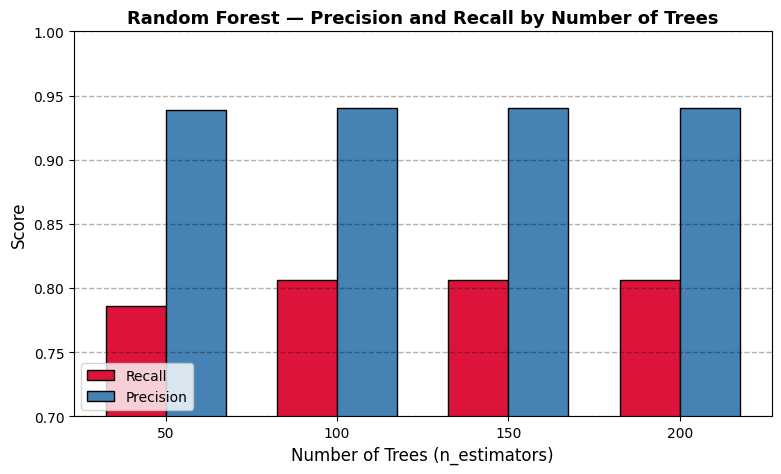

In [3]:
n_values = [50, 100, 150, 200]

# np.arange creates evenly spaced positions
x = np.arange(len(n_values))
width = 0.35 # width of each bar

# Two bars per group
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, rf_recall_scores,   width, label='Recall',    color='crimson',   edgecolor='black')
ax.bar(x + width/2, rf_precision_scores, width, label='Precision', color='steelblue', edgecolor='black')
ax.grid(True, alpha=0.3, axis='y', color='black', linestyle='--', linewidth=1)

ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest — Precision and Recall by Number of Trees', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(n_values) # replace 0,1,2,3 with actual n_estimator values
ax.set_xticks(x)
ax.set_ylim(0.70, 1.0) # start at 0.70 so differences are visible
ax.legend(loc='lower left')
plt.show()

## 4. Logistic Regression — Diffrent Model Strengths (C)

`C` controls how strict the model is with itself

In c the difference between 0.01 and 0.1 is just as meaningful as between 1 and 10.

In [1]:
lr_recall_scores = []
lr_precision_scores = []
lr_f1_scores = []

# Loop through four values of C
for c in [0.01, 0.1, 1, 10]:
    # C controls how strict the model is with itself
    lr = LogisticRegression(C=c, max_iter=1000, random_state=42)

    # fit() trains the model — it learns the weights for each feature from training data
    lr.fit(X_train, y_train)
    
    predict_y_train = lr.predict(X_train) # predictions on training data
    predict_y_test = lr.predict(X_test) # predictions on test data

    # Store metrics for the chart
    lr_recall_scores.append(recall_score(y_test, predict_y_test))
    lr_precision_scores.append(precision_score(y_test, predict_y_test))
    lr_f1_scores.append(f1_score(y_test, predict_y_test))

    # classification_report prints Precision, Recall, F1 and Support for each class
    print(f'\nLogistic Regression with C={c}')
    print('='*55)
    print(classification_report(y_test, predict_y_test, target_names=['Legitimate', 'Fraud']))

NameError: name 'LogisticRegression' is not defined

## 5. Logistic Regression — Results Chart

**Key finding:** Logistic Regression shows minimal changes to C

lower recall compared to Random Forest
further supports the choice of Random Forest as the primary model


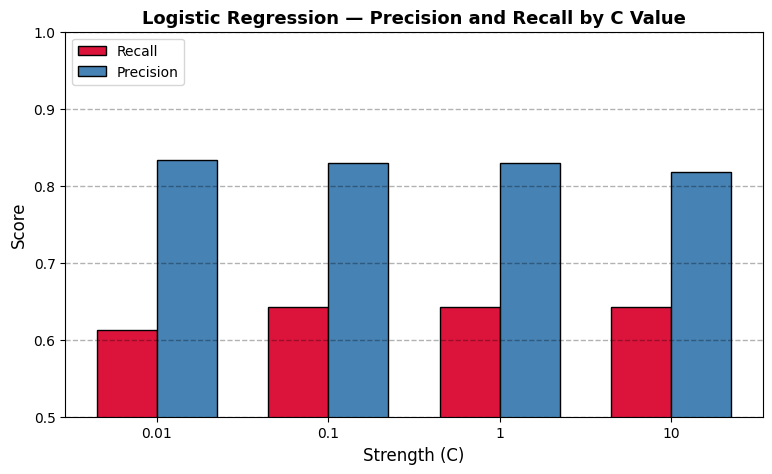

In [5]:
c_values = ['0.01', '0.1', '1', '10']

x = np.arange(len(c_values))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lr_recall_scores,   width, label='Recall',    color='crimson',   edgecolor='black')
ax.bar(x + width/2, lr_precision_scores, width, label='Precision', color='steelblue', edgecolor='black')
ax.grid(True, alpha=0.3, axis='y', color='black', linestyle='--', linewidth=1)

ax.set_xlabel('Strength (C)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Logistic Regression — Precision and Recall by C Value', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(c_values)
ax.set_xticks(x)
ax.set_ylim(0.50, 1.0)
ax.legend(loc='upper left')
plt.show()

## 6. Random Forest — class_weight='balanced'

`class_weight='balanced'` tells the model to pay more attention to the minority class during training

**Hypothesis:** This should improve recall by making the model more aggressive about catching fraud

In [6]:
rf_precision_scores_balanced = []
rf_recall_scores_balanced = []
rf_f1_scores_balanced = []

# Same loop as Section 2 but with class_weight='balanced'
for n in [50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
    # fit() trains all n trees on the training data
    rf.fit(X_train, y_train)

    predict_rf_train = rf.predict(X_train) # predictions on training data
    predict_rf_test = rf.predict(X_test) # predictions on test data

     # Store metrics for the chart
    rf_recall_scores_balanced.append(recall_score(y_test, predict_rf_test))
    rf_precision_scores_balanced.append(precision_score(y_test, predict_rf_test))
    rf_f1_scores_balanced.append(f1_score(y_test, predict_rf_test))

    # classification_report prints Precision, Recall, F1 and Support for each class
    print(f'\nRandom Forest(Balanced) with n_estimators={n}')
    print('='*55)
    print(classification_report(y_test, predict_rf_test, target_names=['Legitimate', 'Fraud']))


Random Forest(Balanced) with n_estimators=50
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Random Forest(Balanced) with n_estimators=100
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.73      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Random Forest(Balanced) with n_estimators=150
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.95      0.74      0.83        98

    accuracy                           1.0

## 7. Logistic Regression — class_weight='balanced'

Same experiment applied to Logistic Regression


In [7]:
lr_precision_scores_balanced = []
lr_recall_scores_balanced = []
lr_f1_scores_balanced = []

# Same loop as Section 2 but with class_weight='balanced'
for c in [0.01, 0.1, 1, 10]:
    lr = LogisticRegression(C=c, max_iter=1000, class_weight='balanced', random_state=42)

    # fit() trains all n trees on the training data 
    lr.fit(X_train, y_train)
    
    predict_y_train = lr.predict(X_train) # predictions on training data
    predict_y_test = lr.predict(X_test) # predictions on test data
    
    # Store metrics for the chart
    lr_recall_scores_balanced.append(recall_score(y_test, predict_y_test))
    lr_precision_scores_balanced.append(precision_score(y_test, predict_y_test))
    lr_f1_scores_balanced.append(f1_score(y_test, predict_y_test))

    # classification_report prints Precision, Recall, F1 and Support for each class
    print(f'\nLogistic Regression(Balanced) with C={c}')
    print('='*55)
    print(classification_report(y_test, predict_y_test, target_names=['Legitimate', 'Fraud']))


Logistic Regression(Balanced) with C=0.01
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Logistic Regression(Balanced) with C=0.1
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.98     56962


Logistic Regression(Balanced) with C=1
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   

## 8. Final Graph of All Models 

chart compares the best result from each configuration:
- **RF Default** — n_estimators=100
- **RF Balanced** — n_estimators=100, class_weight='balanced'
- **LR Default** — C=1
- **LR Balanced** — C=1, class_weight='balanced'

**Key findings:**
- RF Default remains the best practical model
- LR Balanced is impractical

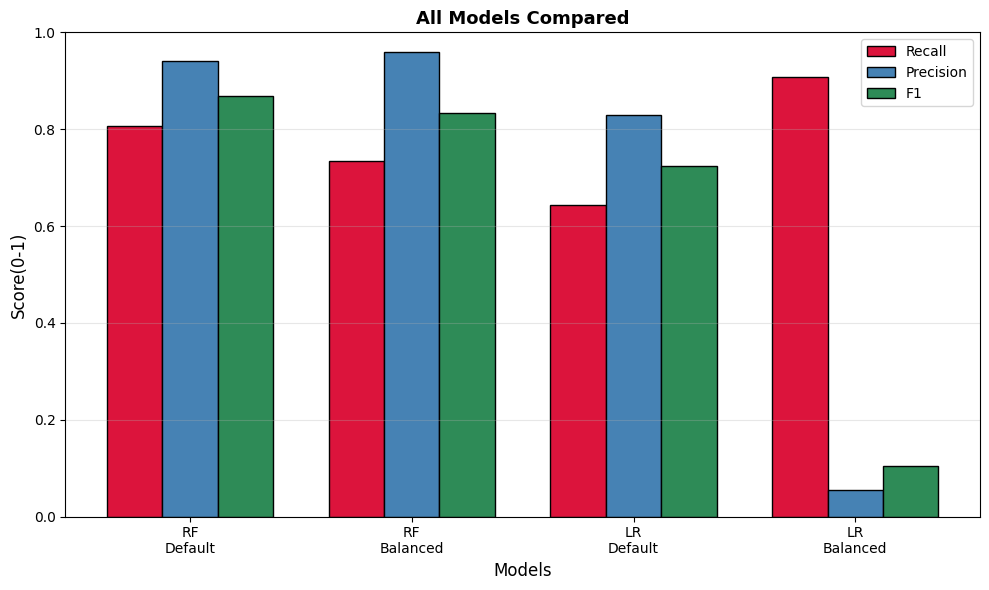

In [8]:
models = ['RF\nDefault', 'RF\nBalanced', 'LR\nDefault', 'LR\nBalanced']
recall_scores    = [rf_recall_scores[1], rf_recall_scores_balanced[1], lr_recall_scores[2], lr_recall_scores_balanced[2]]
precision_scores = [rf_precision_scores[1], rf_precision_scores_balanced[1], lr_precision_scores[2], lr_precision_scores_balanced[2]]
f1_scores        = [rf_f1_scores[1], rf_f1_scores_balanced[1], lr_f1_scores[2], lr_f1_scores_balanced[2]]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, recall_scores,    width, label='Recall',    color='crimson',   edgecolor='black')
ax.bar(x,         precision_scores, width, label='Precision', color='steelblue', edgecolor='black')
ax.bar(x + width, f1_scores,        width, label='F1',        color='seagreen',  edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score(0-1)', fontsize=12)
ax.set_title('All Models Compared', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()